This notebook is the analytical core of the **LLM Semantic Explorer** project. 

While the [3D Web Application](https://llm-semantic-explorer.vercel.app/) provides an intuitive visual representation of how a Large Language Model navigates its internal conceptual space, this notebook aims to provide the **mathematical and quantitative validation** of those visualizations.


The analysis is structured into two main sections:
1. Tool Validation (Reliability Metrics)
2. Space Exploration Dynamics (Prompt Engineering Impact)

# Setup and Configuration

In [1]:
from collections import Counter
from pathlib import Path
from scipy.spatial.distance import cosine
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness
import json
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("charts", exist_ok=True)

# 1. Tool Validation (Reliability Metrics)
Before analyzing the model's behavior, we must prove that our dimensionality reduction (UMAP) and clustering (HDBSCAN) techniques do not distort the underlying semantic reality. 

We will use mathematical metrics to answer two fundamental questions:
* *Does the 3D projection faithfully preserve the original high-dimensional neighborhoods?*
* *Are the identified semantic clusters mathematically distinct and robust?*

Dimensionality reduction inherently involves a loss of information. To ensure that the visual clusters observed in our Web Application are not mere artifacts of the UMAP projection or the HDBSCAN algorithm, we must mathematically validate the data structure.

In this section, we implement two standard Data Science metrics to prove the robustness of our pipeline:

1.  **Trustworthiness:** Measures if the local neighborhoods in the original space are preserved in the 3D projection.
2.  **Silhouette Score:** Evaluates the density and separation of the semantic clusters generated by HDBSCAN.

## Metric 1: Trustworthiness (Neighborhood Preservation)

It is crucial to verify that the local structure of the data is preserved. If two tokens are semantically similar (close to each other) in the original high-dimensional space of the LLM, they should remain close in our 3D visualization.

**Trustworthiness** measures this exact phenomenon. It quantifies the extent to which the \(k\)-nearest neighbors of a point are preserved during the dimensionality reduction process. 

*   **Range:** \([0, 1]\)
*   **Interpretation:** A score close to 1 indicates that the 3D projection is highly reliable and does not create "fake" semantic relationships (i.e., tokens that appear close in 3D but were actually distant in the original latent space).


In [2]:
def calculate_trustworthiness(dataset, n_neighbors=5):
    """
    Calculates the trustworthiness of the UMAP embedding across all prompt types.
    """
    X_high, X_low = [], []
    
    for path in dataset.get('paths', []):
        for pt in path.get('points', []):
            X_high.append(pt['raw'])
            X_low.append(pt['position'])
            
    if not X_high:
        print("No data points found.")
        return None
        
    X_high = np.array(X_high)
    X_low = np.array(X_low)
    
    score = trustworthiness(X_high, X_low, n_neighbors=n_neighbors)
    print(f"Trustworthiness Score: {score:.4f} ({len(X_high)} total tokens)")
    
    return score

## Metric 2: Silhouette Score (Cluster Density and Separation)

We need to mathematically validate if these clusters actually make sense. Are they dense and well-separated, or are they overlapping and fuzzy?

The **Silhouette Score** is a standard metric for evaluating clustering performance. It calculates how similar a token is to its own cluster (cohesion) compared to the nearest neighboring cluster (separation). 

*   **Range:** \([-1, 1]\)
*   **Interpretation:** 
    *   A score close to **1** means that the clusters are extremely dense and perfectly separated from each other (indicating highly structured topics).
    *   A score around **0** indicates overlapping clusters (topics that blend into each other).
    *   A score near **-1** means tokens have likely been assigned to the wrong clusters.

*Note:* Since HDBSCAN identifies some tokens as "noise" (label `-1`), standard practice dictates filtering out these noise points before calculating the Silhouette Score, to genuinely evaluate the quality of the formed clusters.

In [3]:
def calculate_silhouette(dataset):
    """
    Calculates the Silhouette Score for the HDBSCAN clusters.
    Excludes HDBSCAN noise points (cluster_id == -1).
    """
    X, labels = [], []
    
    for path in dataset.get('paths', []):
        for pt in path.get('points', []):
            X.append(pt['position'])
            labels.append(pt['cluster_id'])
            
    if not X:
        print("No data points found.")
        return None
        
    X = np.array(X)
    labels = np.array(labels)
    
    # Filter out noise points
    valid_indices = labels != -1
    X_clustered = X[valid_indices]
    labels_clustered = labels[valid_indices]
    
    unique_clusters = np.unique(labels_clustered)
    if len(unique_clusters) < 2:
        print("Warning: Less than 2 valid clusters globally. Cannot compute Silhouette.")
        return None
        
    score = silhouette_score(X_clustered, labels_clustered)
    print(f"Silhouette Score: {score:.4f} (across {len(unique_clusters)} clusters, excluding noise)")
    
    return score

# 2. Space Exploration Dynamics (Prompt Engineering Impact)

Having mathematically validated the structural integrity of our 3D projection (UMAP) and the robustness of our clustering (HDBSCAN), we can now shift our focus to the core objective of this study: **evaluating the impact of Prompt Engineering on the LLM's cognitive trajectory.**

The fundamental question we aim to answer is: *How do advanced prompting techniques physically alter the generation path of a Large Language Model within its latent semantic space compared to a naive, zero-shot prompt?*

In this section, we extract and compare metrics to quantify these dynamics:

* **Semantic Divergence:** Measures how much new conceptual territory an advanced prompt forces the model to explore.
* **Semantic Cluster Activation:** Analyzes which specific macro-topics (HDBSCAN clusters) are traversed by the LLM during generation. This metric reveals how advanced prompts force the model to unlock and navigate through specific reasoning areas that are completely ignored by a baseline prompt.

## Metric 3: Semantic Divergence (Auto-Adaptive Jaccard Novelty Ratio)

While analyzing the latent space, a core question arises: *How much strictly "new semantic material" does an advanced prompt unlock compared to a basic one?* 

To measure this, we evaluate the divergence of the generated paths using the **Jaccard Distance** (1 - Jaccard Similarity) on the semantic neighborhoods traversed by the model. We calculate this by discretizing the continuous 3D UMAP space into discrete "semantic sectors" (a 3D grid) and measuring the overlap between the sectors visited by different prompts.

**Methodological Note: Auto-Adaptive Spatial Discretization**
Instead of using an arbitrary, fixed grid resolution, which could over-segment or under-segment the semantic space depending on the length and variance of the text, this metric employs a dynamic approach. We determine the optimal volume of the 3D semantic sectors by applying a 3-dimensional extension of the **Freedman-Diaconis rule**. 

The algorithm calculates the optimal bin width independently for the X, Y, and Z axes based on the Interquartile Range (IQR) and the total number of generated tokens. This ensures that the grid perfectly adapts to the specific semantic density of the current dataset, maximizing the signal-to-noise ratio in our novelty calculations.

* **Interpretation:** The result is expressed as a percentage of **"Semantic Novelty"**.
    * **Low Novelty (~0-20%):** The advanced prompt failed to change the model's core response, effectively traversing the exact same conceptual path as the baseline.
    * **High Novelty (>50%):** The advanced prompt successfully forced the model to explore new cognitive regions, generating a response composed largely of concepts entirely ignored by the baseline prompt.

In [4]:
def calculate_semantic_divergence(dataset, reference_path_index=0):
    """
    Calculates Semantic Divergence (Jaccard Novelty) using an auto-adaptive 3D grid 
    resolution based on a 3D extension of the Freedman-Diaconis rule.
    """
    paths_data = dataset.get('paths', [])
    if len(paths_data) < 2:
        print("Need at least 2 paths to compare divergence.")
        return None
        
    # 1. Extract all positions
    all_positions = []
    for path in paths_data:
        all_positions.extend([pt['position'] for pt in path.get('points', [])])
        
    all_positions = np.array(all_positions)
    n_points = len(all_positions)
    
    if n_points == 0:
        return None
        
    # 2. AUTO-RESOLUTION CALCULATION (Freedman-Diaconis logic for 3D)
    iqr = np.percentile(all_positions, 75, axis=0) - np.percentile(all_positions, 25, axis=0)
    iqr = np.where(iqr == 0, np.std(all_positions, axis=0) + 1e-9, iqr)
    
    # Calculate optimal bin width for each axis
    bin_widths = 2 * iqr / (n_points ** (1/3))
    min_bounds = np.min(all_positions, axis=0)
        
    def get_grid_sector(pos):
        return tuple(np.floor((pos - min_bounds) / bin_widths).astype(int))

    # 3. Map paths to semantic sectors
    path_sectors = {}
    for path in paths_data:
        name = path.get('name', f"Path_{path.get('id')}")
        positions = [pt['position'] for pt in path.get('points', [])]
        path_sectors[name] = set(get_grid_sector(np.array(p)) for p in positions)

    # 4. Calculate Jaccard Novelty
    reference_name = paths_data[reference_path_index].get('name')
    ref_set = path_sectors[reference_name]
    
    results = {}
    print(f"\n--- Semantic Novelty (Baseline: '{reference_name}') ---")
    
    for name, sectors in path_sectors.items():
        if name == reference_name:
            continue
            
        intersection = len(ref_set.intersection(sectors))
        union = len(ref_set.union(sectors))
        
        if union == 0:
            continue
            
        jaccard_dist = 1.0 - (intersection / union)
        novelty_pct = jaccard_dist * 100
        overlap_pct = 100 - novelty_pct
        
        results[name] = {
            'novelty_pct': novelty_pct,
            'overlap_pct': overlap_pct,
            'shared_sectors': intersection,
            'total_sectors': union
        }
        
        print(f"Novelty unlocked by '{name}': {novelty_pct:.1f}%")
        print(f"  Overlap: {overlap_pct:.1f}% | Shared sectors: {intersection} | Total distinct sectors explored: {union}")
        
    return results

## Metric 4: Semantic Cluster Activation (Conceptual Footprint)

The final metric aims to map the specific semantic regions that the LLM traverses during text generation. By leveraging the clusters previously identified by HDBSCAN, we can construct a "conceptual footprint" for each prompt.

This metric calculates the percentage of generated tokens that fall into each distinct semantic cluster (excluding noise). 

* **Interpretation:** A baseline (zero-shot) prompt typically generates a narrow footprint, often constrained to basic vocabulary or generic response clusters. Conversely, advanced prompting techniques (like Persona or Chain-of-Thought) force the LLM to navigate through highly specific cognitive areas, demonstrating that the prompt successfully unlocked targeted regions of the latent space that were otherwise inaccessible.

In [5]:
def calculate_cluster_activation(dataset, filename, save_plot=True):
    """
    Analyzes which HDBSCAN clusters are activated by each prompt, calculating the 
    percentage of tokens spent in each semantic area (excluding noise).
    Then, it generates a unified semantic dashboard with two panels:
    - Top: Semantic Trajectory Timeline
    - Bottom: Conceptual Footprint
    """
    results = {}
    cluster_names = {}
    
    # 1. Map cluster IDs to their descriptive names
    for cluster in dataset.get('clusters', []):
        cid = cluster.get('id')
        cname = cluster.get('name') if cluster.get('name') else f"Cluster {cid}"
        if cid != -1:  # Ignore noise mapping for the bar chart
            cluster_names[cid] = cname
            
    # 2. Count tokens per cluster for each path
    all_active_clusters = set()
    paths = dataset.get('paths', [])
    
    for path in paths:
        path_name = path.get('name') if path.get('name') else f"Path {path.get('id')}"
        
        # Get all valid cluster IDs for this path (excluding -1 noise)
        valid_clusters = [pt.get('cluster_id') for pt in path.get('points', []) if pt.get('cluster_id') != -1]
        
        if not valid_clusters:
            results[path_name] = {}
            continue
            
        total_valid_tokens = len(valid_clusters)
        cluster_counts = Counter(valid_clusters)
        
        # Calculate percentages
        activation_percentages = {cid: (count / total_valid_tokens) * 100 for cid, count in cluster_counts.items()}
        results[path_name] = activation_percentages
        all_active_clusters.update(activation_percentages.keys())
        
        # Print results to console
        print(f"\n--- Conceptual Footprint for {path_name} ---")
        for cid, pct in sorted(activation_percentages.items(), key=lambda x: x[1], reverse=True):
            name = cluster_names.get(cid, f"Cluster {cid}")
            print(f"{name}: {pct:.1f}% of tokens")

    # ==========================================
    # GENERATE DASHBOARD
    # ==========================================
    if save_plot and paths:
        # Retrieve all clusters including noise for the timeline
        all_clusters_timeline = set()
        for path in paths:
            for pt in path.get('points', []):
                all_clusters_timeline.add(pt.get('cluster_id'))
                
        sorted_clusters_timeline = sorted(list(all_clusters_timeline))
        
        # Prepare the common color map
        num_valid_clusters = len([c for c in sorted_clusters_timeline if c != -1])
        base_colors = plt.cm.tab20(np.linspace(0, 1, max(1, num_valid_clusters)))
        
        color_map = {}
        color_map_hex = {}
        color_idx = 0
        for cid in sorted_clusters_timeline:
            if cid == -1:
                color_map[cid] = mcolors.to_rgba('lightgray')
                color_map_hex[cid] = 'lightgray'
            else:
                color_map[cid] = mcolors.to_rgba(base_colors[color_idx])
                color_map_hex[cid] = base_colors[color_idx]
                color_idx += 1

        path_names = list(results.keys())
        max_len = max(len(p.get('points', [])) for p in paths)
        num_paths = len(paths)
        
        # Setup Subplots 
        fig, (ax1, ax2) = plt.subplots(
            nrows=2, 
            ncols=1, 
            figsize=(14, 9 + (num_paths * 0.4)), 
            gridspec_kw={'height_ratios': [1.2, 1]} 
        )
        
        # --- PANEL 1: SEMANTIC TIMELINE ---
        for y_idx, path in enumerate(paths):
            points = path.get('points', [])
            if not points:
                continue
                
            row_img = np.zeros((1, len(points), 4))
            for x_idx, pt in enumerate(points):
                row_img[0, x_idx] = color_map[pt.get('cluster_id')]

            ax1.imshow(
                row_img, 
                extent=[0, len(points), y_idx + 0.4, y_idx - 0.4], 
                aspect='auto', 
                interpolation='nearest'
            )
        
        ax1.set_ylim(num_paths - 0.5, -0.5)
        ax1.set_xlim(0, max_len)
        ax1.set_yticks(range(num_paths))
        ax1.set_yticklabels(path_names, fontsize=10)
        ax1.set_xlabel("Token Sequence (Temporal Generation)", fontsize=11, fontweight='bold')
        ax1.set_title("Semantic Trajectory Timeline", fontsize=14, fontweight='bold', pad=15)
        
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_visible(False)
        ax1.spines['bottom'].set_visible(False)
        ax1.tick_params(axis='y', which='both', length=0)

        # --- PANEL 2: CONCEPTUAL FOOTPRINT (Bar Chart) ---
        bottoms = np.zeros(len(path_names))
        sorted_clusters_bar = sorted(list(all_active_clusters))
        
        for cid in sorted_clusters_bar:
            values = [results[p].get(cid, 0.0) for p in path_names]
            if sum(values) > 0:
                ax2.bar(
                    path_names, 
                    values, 
                    bottom=bottoms, 
                    color=color_map_hex[cid], 
                    edgecolor='white',
                    width=0.6
                )
                bottoms += values
                
        ax2.set_title("Semantic Cluster Activation (Conceptual Footprint)", fontsize=14, fontweight='bold', pad=15)
        ax2.set_ylabel("Percentage of Tokens (%)", fontsize=11, fontweight='bold')
        ax2.set_ylim(0, 100)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)

        # --- SHARED LEGEND ---
        legend_patches = []
        for cid in sorted_clusters_timeline:
            cname = f"Cluster {cid}"
            if cid != -1:
                for cl in dataset.get('clusters', []):
                    if cl.get('id') == cid:
                        cname = cl.get('name') if cl.get('name') else cname
                        break
            else:
                cname = 'Noise (-1)'
                
            patch = mpatches.Patch(color=color_map_hex[cid], label=cname)
            legend_patches.append(patch)
            
        ax1.legend(
            handles=legend_patches,
            title="Semantic Clusters",
            loc='upper left',           
            bbox_to_anchor=(1.02, 1.05),  
            ncol=1,                      
            fontsize='10',
            title_fontsize='12',
            frameon=False
        )
        
        plt.subplots_adjust(hspace=0.4, right=0.8)
        
        plt.savefig(f"charts/{filename}_cluster_activation.png", dpi=300, bbox_inches='tight')
        plt.show()

    return results

# Main Metrics Computation

In [6]:
def load_inputs():
    input_dir = '/kaggle/input/notebooks/dammafra/llm-semantic-explorer-pipeline/out/full'
    inputs = {}
    
    for dirname, _, filenames in os.walk(input_dir):
        for filename in filenames:
            if filename.endswith('.json'):
                file_path = os.path.join(dirname, filename)
                with open(file_path, 'r', encoding='utf-8') as file:
                    inputs[Path(filename).stem] = json.load(file)

    return inputs

In [7]:
# A small helper class to handle numpy data types (float32, int64) 
# which are not natively supported by Python's built-in JSON encoder
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

def export_to_json(filename, trustworthiness_score, silhouette_score, divergence_results, cluster_activations):
    """
    Exports the calculated results of the 4 metrics into a formatted JSON file.
    """
    
    # Structure the final data dictionary
    metrics_data = {
        "trustworthiness_score": trustworthiness_score,
        "silhouette_score": silhouette_score,
        "semantic_divergence": divergence_results,
        "cluster_activation": cluster_activations
    }
    
    output_path = f"{filename}_metrics.json"
    
    # Write the dictionary to a JSON file
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(metrics_data, f, indent=4, cls=NpEncoder)
        
    print(f"[*] Metrics successfully exported to: {output_path}")

In [8]:
def metrics_computation(filename, dataset):
    print(f"\n=== Processing {filename} ===")
    
    trustworthiness_score = calculate_trustworthiness(dataset)
    silhouette_score = calculate_silhouette(dataset)

    semantic_divergence = calculate_semantic_divergence(dataset)
    cluster_activation = calculate_cluster_activation(dataset, filename)

    export_to_json(
        filename, 
        trustworthiness_score,
        silhouette_score,
        semantic_divergence,
        cluster_activation
    )
    
    print("\n")

Loading inputs...

=== Processing chain-of-thought ===
Trustworthiness Score: 0.9656 (96 total tokens)
Silhouette Score: 0.7430 (across 2 clusters, excluding noise)

--- Semantic Novelty (Baseline: 'bad_prompt') ---
Novelty unlocked by 'good_prompt': 95.2%
  Overlap: 4.8% | Shared sectors: 2 | Total distinct sectors explored: 42

--- Conceptual Footprint for bad_prompt ---
Social Interaction: 100.0% of tokens

--- Conceptual Footprint for good_prompt ---
Social Interaction: 92.4% of tokens
Number Sequence: 7.6% of tokens


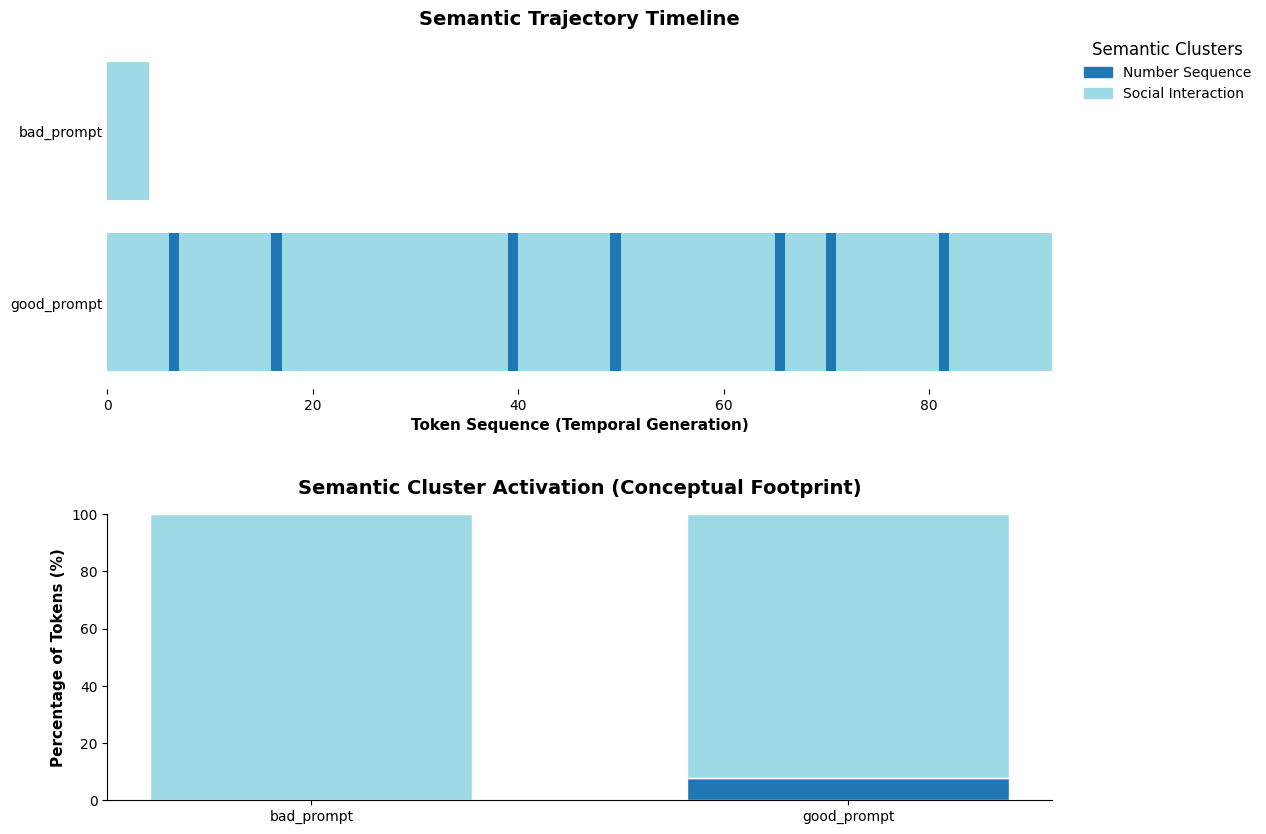

[*] Metrics successfully exported to: chain-of-thought_metrics.json



=== Processing few-shot-prompting ===
Trustworthiness Score: 0.9355 (34 total tokens)
Silhouette Score: 0.5363 (across 2 clusters, excluding noise)

--- Semantic Novelty (Baseline: 'bad_prompt') ---
Novelty unlocked by 'good_prompt': 96.3%
  Overlap: 3.7% | Shared sectors: 1 | Total distinct sectors explored: 27

--- Conceptual Footprint for bad_prompt ---
Customer Complaint: 100.0% of tokens

--- Conceptual Footprint for good_prompt ---
Customer Complaint: 60.0% of tokens
Customer Order Details: 40.0% of tokens


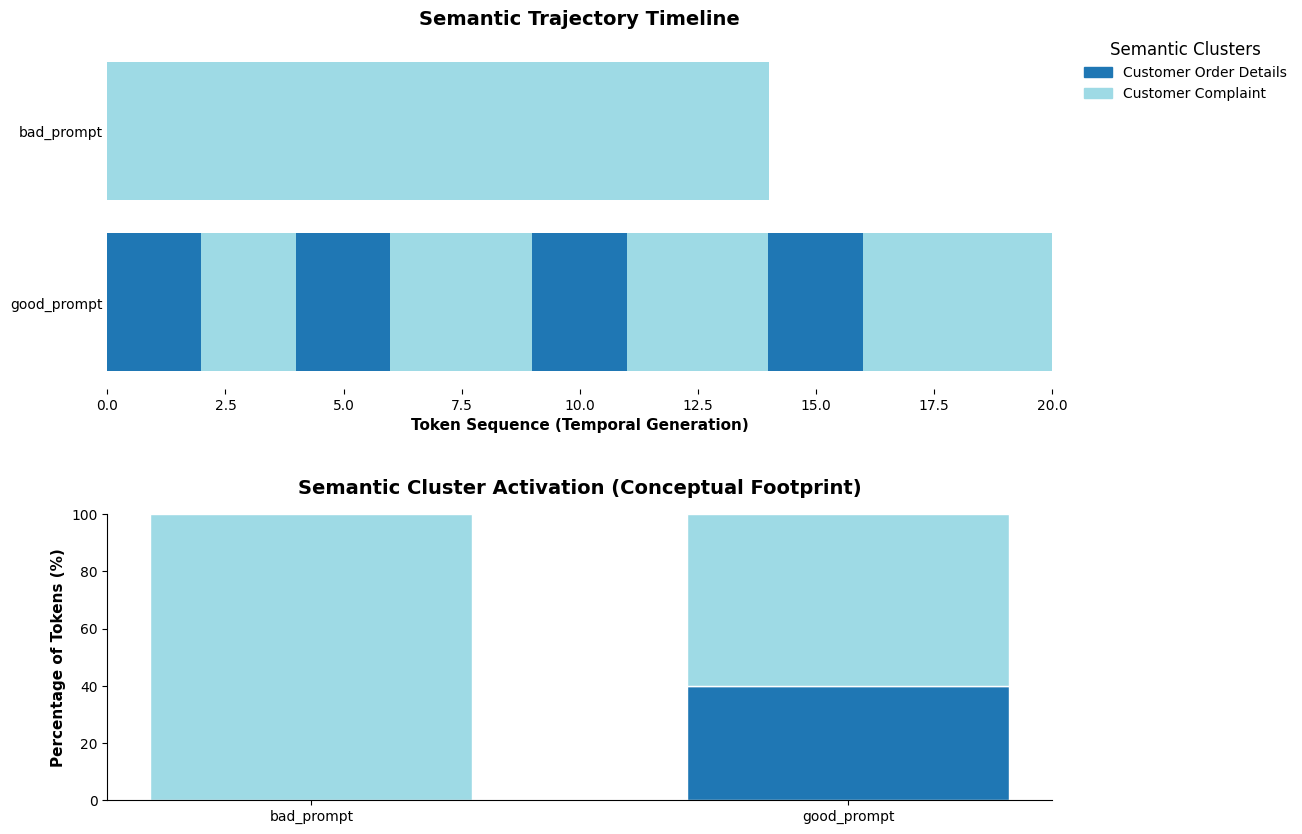

[*] Metrics successfully exported to: few-shot-prompting_metrics.json



=== Processing prompt-chaining ===
Trustworthiness Score: 0.9595 (335 total tokens)
Silhouette Score: 0.4839 (across 24 clusters, excluding noise)

--- Semantic Novelty (Baseline: 'bad_prompt') ---
Novelty unlocked by 'prompt_chaining_1': 85.5%
  Overlap: 14.5% | Shared sectors: 16 | Total distinct sectors explored: 110
Novelty unlocked by 'prompt_chaining_2': 97.2%
  Overlap: 2.8% | Shared sectors: 2 | Total distinct sectors explored: 71
Novelty unlocked by 'prompt_chaining_3': 94.0%
  Overlap: 6.0% | Shared sectors: 5 | Total distinct sectors explored: 83

--- Conceptual Footprint for bad_prompt ---
Scientific Discovery: 20.9% of tokens
Science Fiction: 13.9% of tokens
Threatening Entity: 11.3% of tokens
Science Fiction Story: 7.8% of tokens
Post Apocalyptic Fiction: 7.8% of tokens
Future Mission Forces: 6.1% of tokens
Occupational Professions: 6.1% of tokens
Numbered Names: 6.1% of tokens
Exceptional Individual

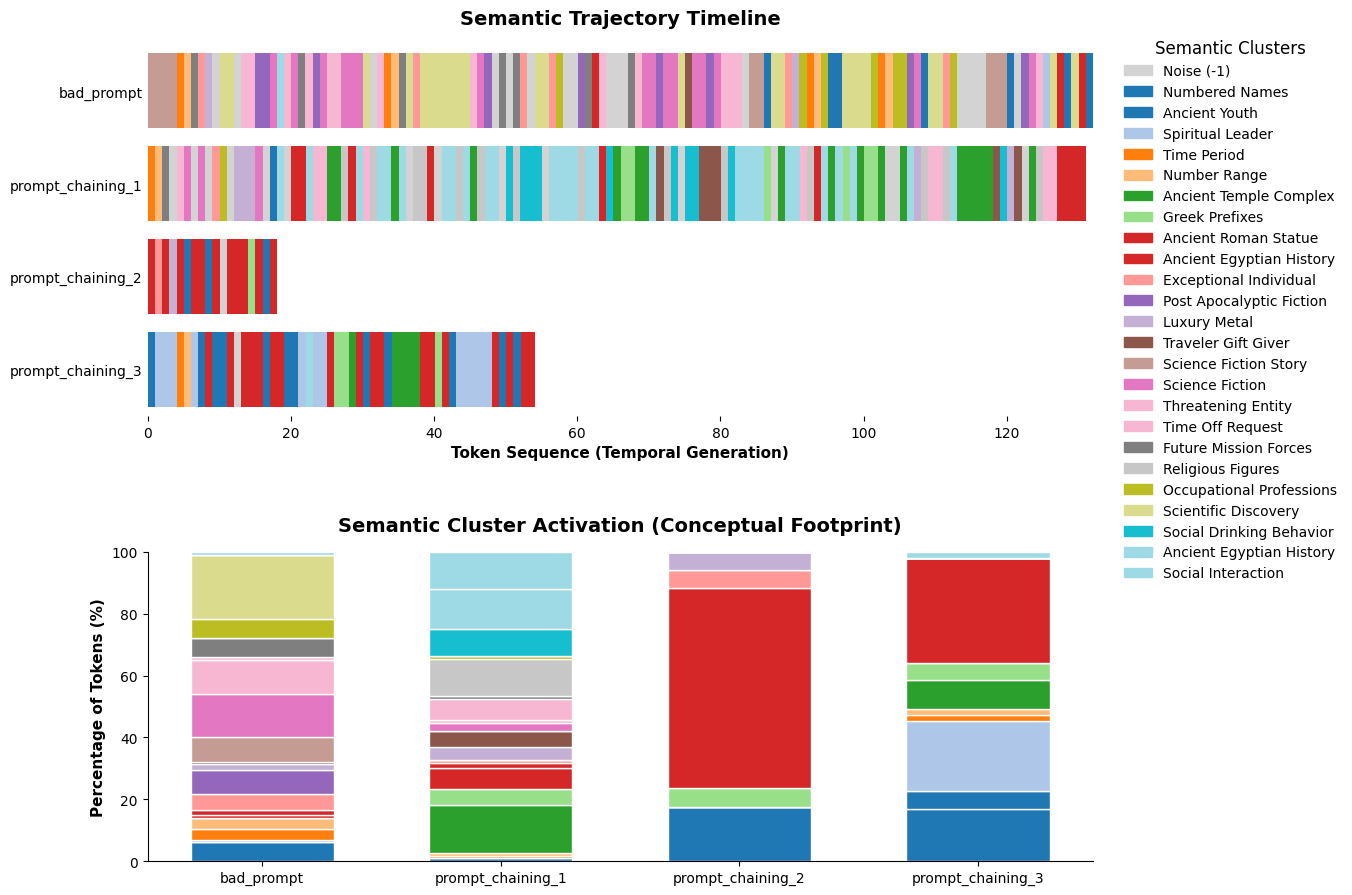

[*] Metrics successfully exported to: prompt-chaining_metrics.json



=== Processing tree-of-thoughts ===
Trustworthiness Score: 0.9670 (461 total tokens)
Silhouette Score: 0.5203 (across 34 clusters, excluding noise)

--- Semantic Novelty (Baseline: 'bad_prompt') ---
Novelty unlocked by 'tree_of_thoughts_1': 80.0%
  Overlap: 20.0% | Shared sectors: 11 | Total distinct sectors explored: 55
Novelty unlocked by 'tree_of_thoughts_2': 92.1%
  Overlap: 7.9% | Shared sectors: 5 | Total distinct sectors explored: 63
Novelty unlocked by 'tree_of_thoughts_3': 94.8%
  Overlap: 5.2% | Shared sectors: 3 | Total distinct sectors explored: 58
Novelty unlocked by 'tree_of_thoughts_4': 94.4%
  Overlap: 5.6% | Shared sectors: 4 | Total distinct sectors explored: 72

--- Conceptual Footprint for bad_prompt ---
Marketing And Advertising: 25.4% of tokens
Community Media Subscription: 12.7% of tokens
Marketing Strategy: 11.1% of tokens
Coffee Delivery Service: 11.1% of tokens
Cozy Coffee Culture: 7.9% of t

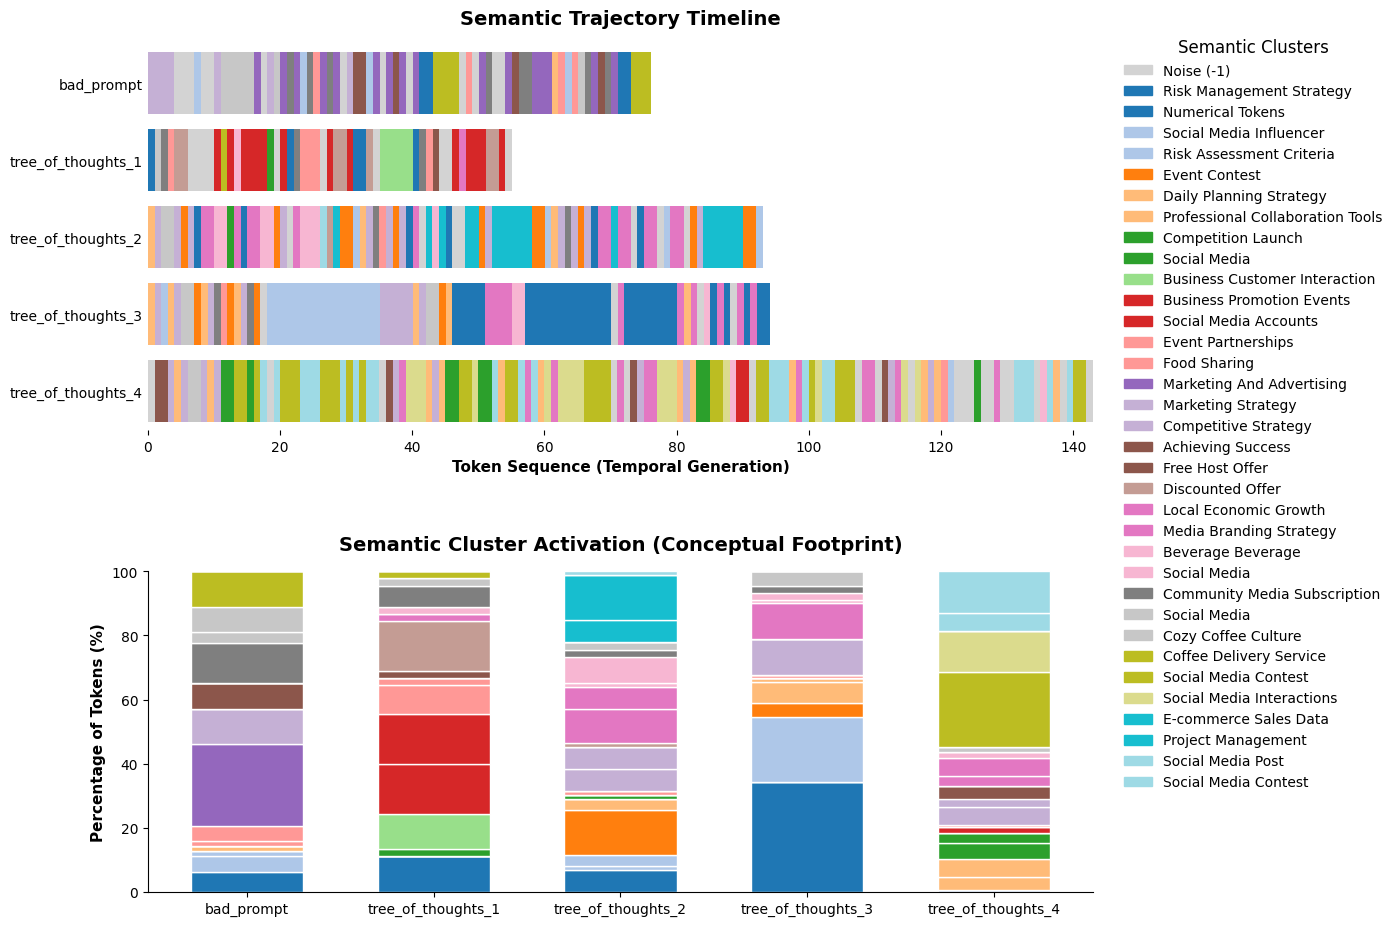

[*] Metrics successfully exported to: tree-of-thoughts_metrics.json



=== Processing step-back-prompting ===
Trustworthiness Score: 0.9592 (309 total tokens)
Silhouette Score: 0.4116 (across 5 clusters, excluding noise)

--- Semantic Novelty (Baseline: 'bad_prompt') ---
Novelty unlocked by 'step_back_1': 87.8%
  Overlap: 12.2% | Shared sectors: 10 | Total distinct sectors explored: 82
Novelty unlocked by 'step_back_2': 73.0%
  Overlap: 27.0% | Shared sectors: 17 | Total distinct sectors explored: 63

--- Conceptual Footprint for bad_prompt ---
Digital Marketing Strategies: 90.2% of tokens
Number Sequence: 9.8% of tokens

--- Conceptual Footprint for step_back_1 ---
Digital Marketing Strategies: 70.9% of tokens
Business Process Management: 10.1% of tokens
Digital Customer Service: 8.8% of tokens
Number Sequence: 6.8% of tokens
Social Media Platform: 3.4% of tokens

--- Conceptual Footprint for step_back_2 ---
Digital Marketing Strategies: 86.2% of tokens
Social Media Platform: 5.5% of 

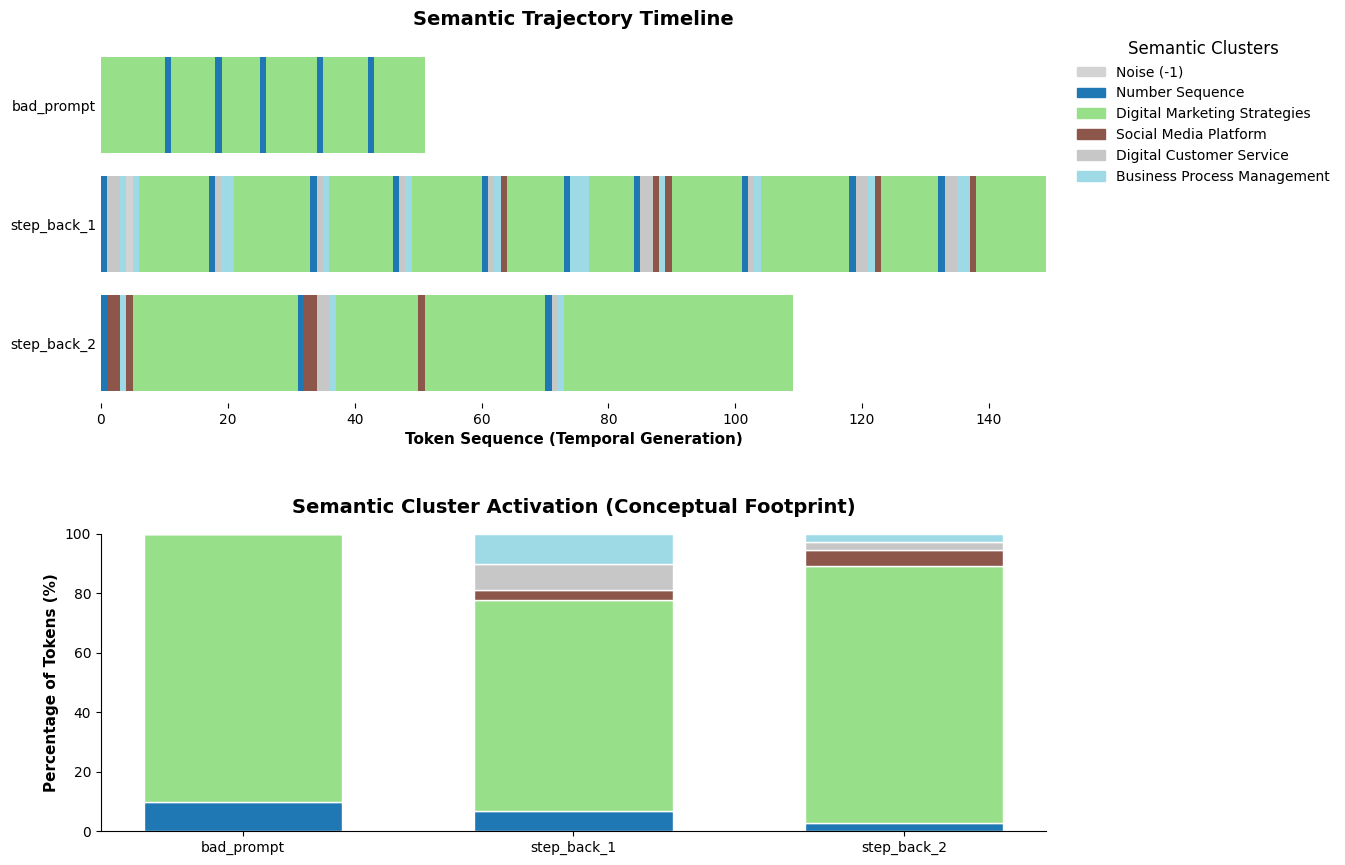

[*] Metrics successfully exported to: step-back-prompting_metrics.json



=== Processing persona-prompting ===
Trustworthiness Score: 0.9337 (93 total tokens)
Silhouette Score: 0.4661 (across 2 clusters, excluding noise)

--- Semantic Novelty (Baseline: 'bad_prompt') ---
Novelty unlocked by 'good_prompt': 85.7%
  Overlap: 14.3% | Shared sectors: 8 | Total distinct sectors explored: 56

--- Conceptual Footprint for bad_prompt ---
Job Application Process: 70.0% of tokens
Formal Job Application: 30.0% of tokens

--- Conceptual Footprint for good_prompt ---
Job Application Process: 87.7% of tokens
Formal Job Application: 12.3% of tokens


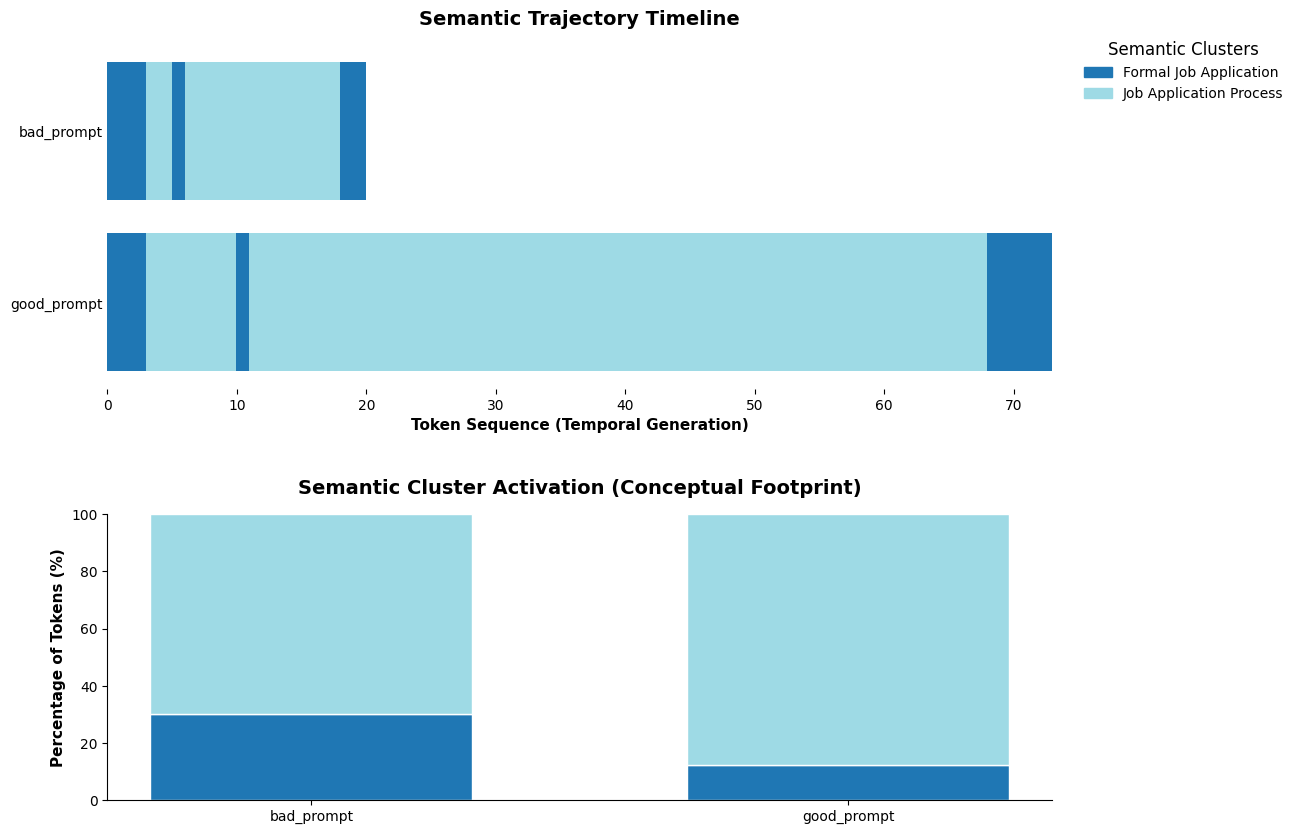

[*] Metrics successfully exported to: persona-prompting_metrics.json




In [9]:
def main():
    print("Loading inputs...")
    inputs = load_inputs()
                
    for technique, dataset in inputs.items():
        metrics_computation(technique, dataset)

main()